In [2]:
import os
import os.path as osp
from glob import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, gaussian_kde, spearmanr, kendalltau
import itertools
import numpy as np

## Dataset Stats

In [2]:
smart_logic_pdb_ids = glob("/ai/share/workspace/sxia/smart_logic_data/*/????")
smart_logic_pdb_ids = [osp.basename(f) for f in smart_logic_pdb_ids]
smart_logic_pdb_ids = set(smart_logic_pdb_ids)

In [3]:
print(len(smart_logic_pdb_ids))

3000


In [4]:
coreset_ids = set()
with open("/ai/share/workspace/jhzhou/data/SiPobe_data/keys_coreset.txt") as f:
    for line in f.readlines():
        coreset_ids.add(line.split("\n")[0])

In [5]:
len(coreset_ids)

285

In [6]:
print(len(coreset_ids.intersection(smart_logic_pdb_ids)))

223


In [7]:
lp_test_ids = set()
with open("/ai/share/workspace/jhzhou/sipobe_ensembles/pdbbind2020_keys_LP/test_set_valid.txt") as f:
    for line in f.readlines():
        lp_test_ids.add(line.split("\n")[0])

In [8]:
len(lp_test_ids)

4841

In [9]:
print(len(lp_test_ids.intersection(smart_logic_pdb_ids)))

1317


In [10]:
lp_val_ids = set()
with open("/ai/share/workspace/jhzhou/sipobe_ensembles/pdbbind2020_keys_LP/val_set_valid.txt") as f:
    for line in f.readlines():
        lp_val_ids.add(line.split("\n")[0])

In [11]:
len(lp_val_ids)

2414

In [12]:
print(len(lp_val_ids.intersection(smart_logic_pdb_ids)))

710


In [13]:
lp_train_ids = set()
with open("/ai/share/workspace/jhzhou/sipobe_ensembles/pdbbind2020_keys_LP/train_set_valid.txt") as f:
    for line in f.readlines():
        lp_train_ids.add(line.split("\n")[0])

In [14]:
len(lp_train_ids)

11478

In [15]:
print(len(lp_train_ids.intersection(smart_logic_pdb_ids)))

898


In [16]:
4841-1317

3524

## Training Loss

In [19]:
import matplotlib.pyplot as plt

def parse_log_file(file_path):
    N_PREFIX = len("2025-11-16 03:41:46,269 ")
    epochs = []
    scores = []
    test_scores = []

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        line = line[N_PREFIX:]
        if "Epoch" in line:
            # Extract the epoch number from the line
            epoch = int(line.split(' ')[1])
            epochs.append(epoch)
        elif "Score" in line and "Test_Score" in line:
            if "Score_MD" in line:
                continue
            # Extract Score and Test_Score values
            parts = line.strip().split(',')
            score = float(parts[0].split(' ')[1])
            test_score = float(parts[1].split(' ')[2])
            scores.append(score)
            test_scores.append(test_score)

    return epochs, scores, test_scores

def plot_training_curve(epochs, scores, test_scores):
    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 16})
    plt.plot(epochs, scores, label="Training Loss")
    plt.plot(epochs, test_scores, label="Validation Loss", linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    # plt.title('Training and Validation Score Over Epochs')
    plt.ylim(bottom=0)
    plt.legend()
    plt.grid(False)
    plt.show()

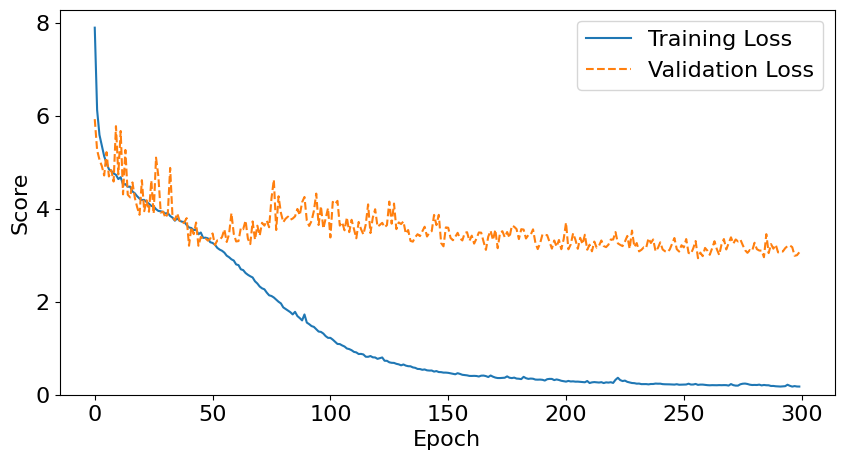

In [20]:
log_file_path = '/ai/share/workspace/sxia/scripts/pignet_md_dev/results_casf/casf_md3000_head16_bs4/training.log'
epochs, scores, test_scores = parse_log_file(log_file_path)
plot_training_curve(epochs, scores, test_scores)

In [21]:
311*300/3600

25.916666666666668

## Enzyme by Class

In [2]:
classify_df = pd.read_csv("pdbbind_2020_pharos_classified.csv", sep="\t")
affinity_file = "/ai/share/workspace/jhzhou/data/SiPobe_data/pdb_to_affinity_scoring.csv"
with open(affinity_file) as f:
    lines = f.readlines()
    lines = [l.split(',') for l in lines]
    id_to_y = {l[0]: float(l[1].split('\n')[0]) for l in lines}

In [3]:
set(classify_df["pharos_family"].values.tolist())

{'Enzyme',
 'Epigenetic',
 'GPCR',
 'Ion Channel',
 'Kinase',
 'Nuclear Receptor',
 'Other',
 'TF-Epigenetic',
 'Transcription Factor',
 'Transporter',
 'Unclassified'}

/tmp/ipykernel_2077793/20529076.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right',  rotation_mode='anchor')


[Text(0, 0, 'Unclassified'),
 Text(1, 0, 'Other'),
 Text(2, 0, 'Enzyme'),
 Text(3, 0, 'Kinase'),
 Text(4, 0, 'Nuclear Receptor'),
 Text(5, 0, 'Ion Channel'),
 Text(6, 0, 'Epigenetic'),
 Text(7, 0, 'Transcription Factor'),
 Text(8, 0, 'Transporter'),
 Text(9, 0, 'GPCR'),
 Text(10, 0, 'TF-Epigenetic')]

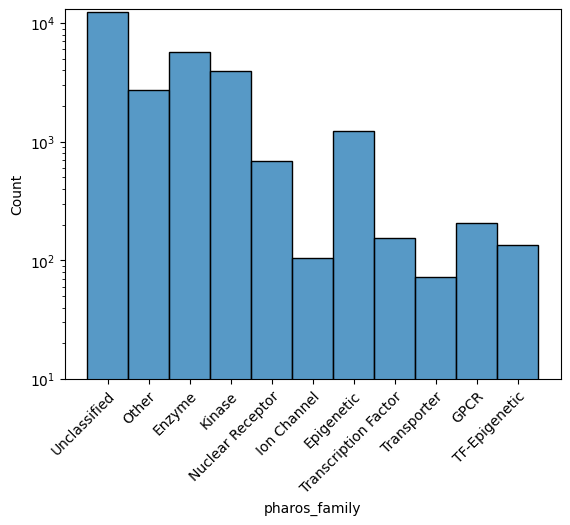

In [4]:
fig, ax = plt.subplots()
sns.histplot(classify_df, x="pharos_family", ax=ax)
ax.set_ylim(bottom=10)
ax.set_yscale("log")
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right',  rotation_mode='anchor')

In [5]:
plt.rcParams['font.size'] = 18
def vis_pred_df(md_workdir):
    score_csv = osp.join(md_workdir, "test_scores", "scores_lp_pdbbind.csv")
    score_df = pd.read_csv(score_csv).set_index("#code")
    print(score_df.shape)
    score_df = score_df.join(classify_df.set_index("pdbid"), how="left")
    paffi = []
    for i in range(score_df.shape[0]):
        this_info = score_df.iloc[i]
        this_paffi = this_info["paffi"]
        if np.isnan(this_paffi.item()):
            this_paffi = id_to_y[this_info.name]
        paffi.append(this_paffi)
    score_df["paffi"] = paffi
    score_df = score_df.fillna("Other")
    score_df["Predicted paffi"] = score_df["score"] / -1.36
    g = sns.lmplot(
    data=score_df,
    x="Predicted paffi", y="paffi", hue="pharos_family", col="pharos_family", col_wrap=3
    )
    r_all = pearsonr(score_df['Predicted paffi'].values, score_df['paffi'].values)
    print(r_all)

    pearson_by_class = {"pharos_family": [], "Pearson R": []}
    # Iterate through the facets to add R-squared
    for ax in g.axes.flat:
        # Get the data for the current facet
        class_name = ax.get_title().split('=')[1].strip()
        hue_subset = score_df[(score_df['pharos_family'] == class_name)] # Adjust based on your facet variable
        if hue_subset.shape[0] < 2:
            continue
            
        # Calculate R-squared
        r, __ = pearsonr(hue_subset['Predicted paffi'].values, hue_subset['paffi'].values)

        # Add R-squared as text annotation
        # Adjust coordinates as needed for placement
        ax.text(0.05, 0.95 - (0.1 * len(ax.texts)), f'Pearson R : {r:.2f}',
                transform=ax.transAxes, verticalalignment='top')
        pearson_by_class["pharos_family"].append(class_name)
        pearson_by_class["Pearson R"].append(r)
    return score_df, pd.DataFrame(pearson_by_class)

(4841, 1)
(0.5534351707706548, 0.0)


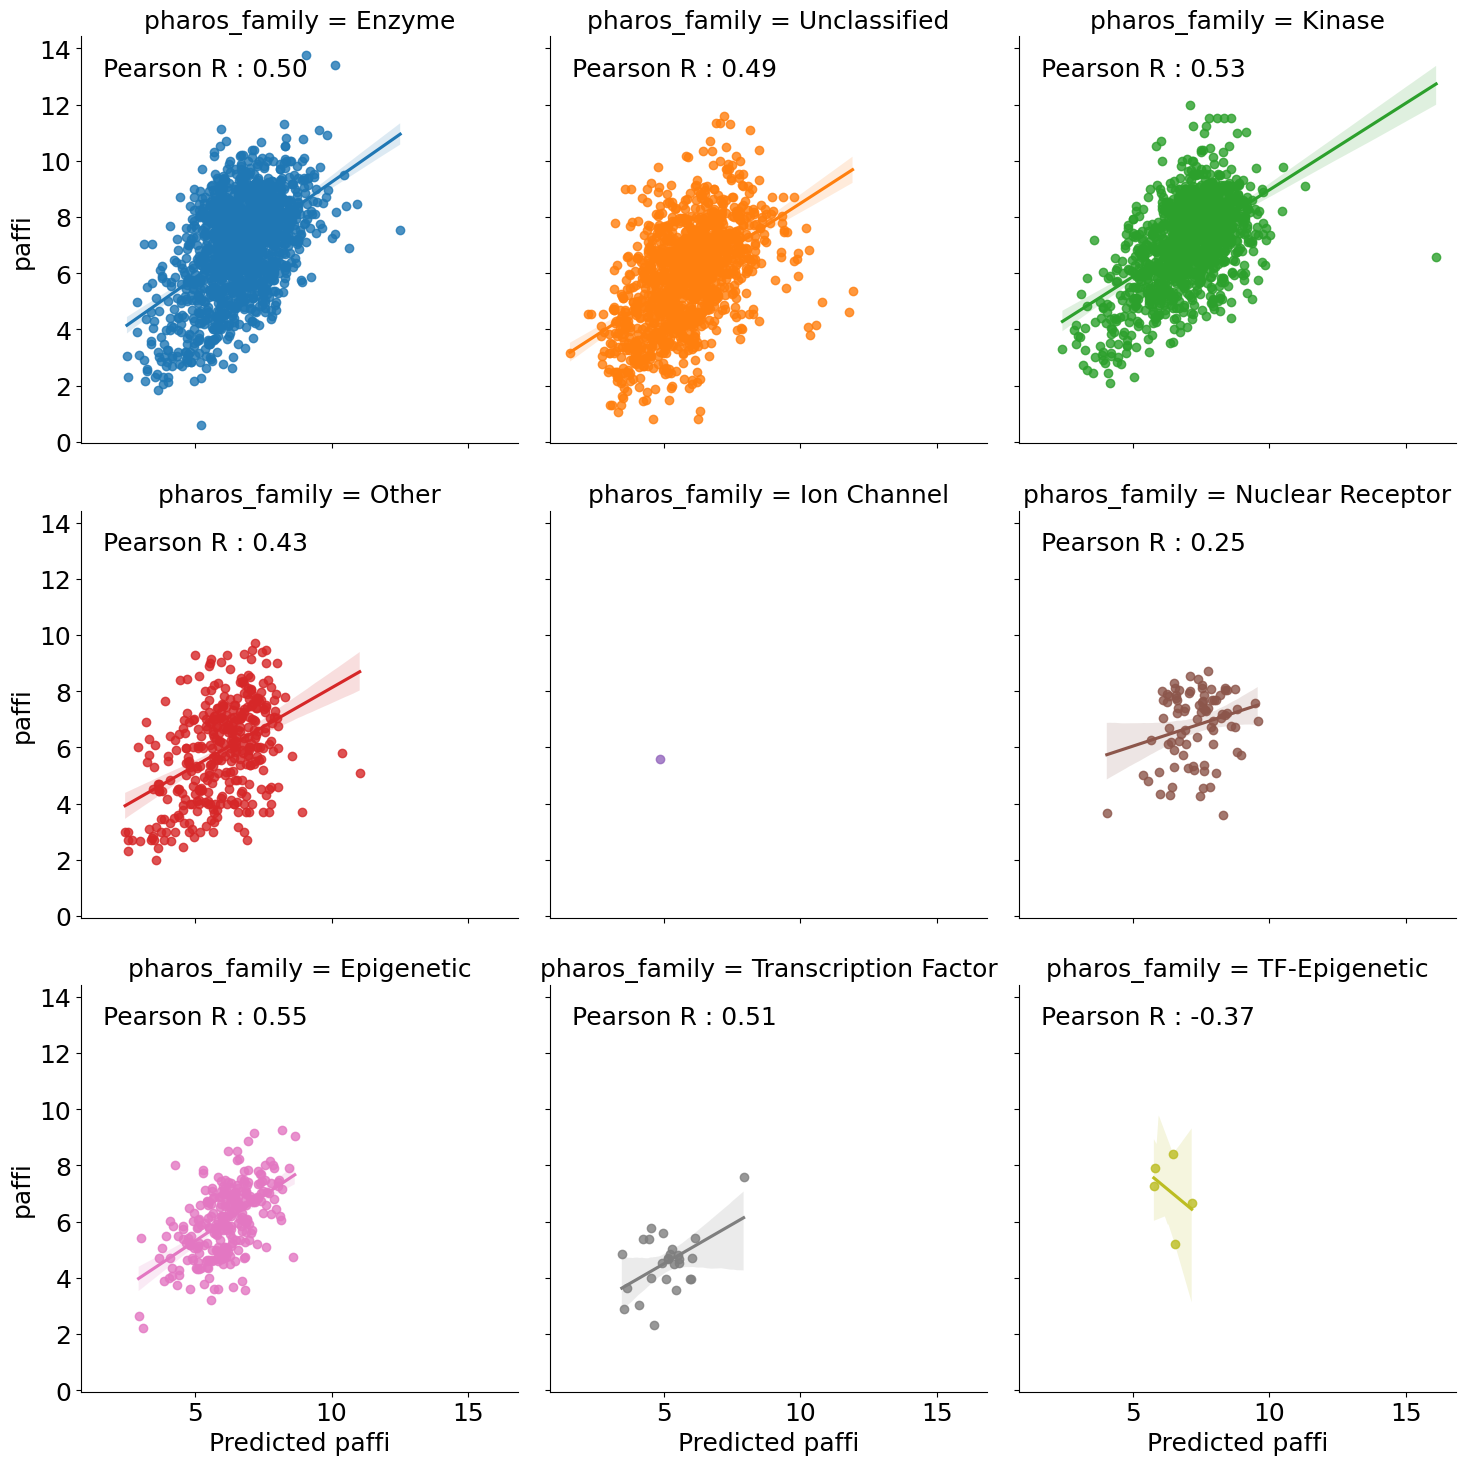

In [6]:
score_df, pearson_by_class = vis_pred_df("/ai/share/workspace/sxia/scripts/pignet_md_dev/results_whole_traj_hptune/lppdbbind_res0.1_frame50_head16_bs4")

/tmp/ipykernel_2077793/454824357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pearson_by_class, x="pharos_family", y="Pearson R", palette="deep", ax=ax)
/tmp/ipykernel_2077793/454824357.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right',  rotation_mode='anchor')


[Text(0, 0, 'Enzyme'),
 Text(1, 0, 'Unclassified'),
 Text(2, 0, 'Kinase'),
 Text(3, 0, 'Other'),
 Text(4, 0, 'Nuclear Receptor'),
 Text(5, 0, 'Epigenetic'),
 Text(6, 0, 'Transcription Factor'),
 Text(7, 0, 'TF-Epigenetic')]

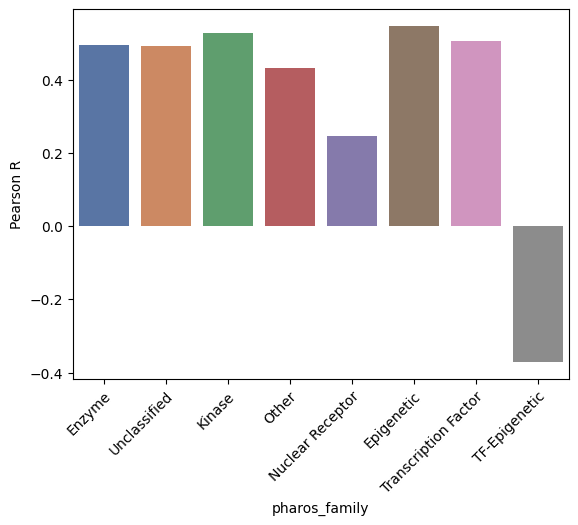

In [7]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots()
sns.barplot(pearson_by_class, x="pharos_family", y="Pearson R", palette="deep", ax=ax)
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right',  rotation_mode='anchor')
# ax.set_ylim(bottom=-0.1)

In [8]:
all_rm_families = ["TF-Epigenetic", "Nuclear Receptor", "Other"]
family2idx = {}
for i, f in enumerate(all_rm_families):
    family2idx[f] = str(i+1)

r_all, __ = pearsonr(score_df['Predicted paffi'].values, score_df['paffi'].values)
out_info = {"Subset": ["All"], "Pearson R": [r_all]}

for i in range(len(all_rm_families)):
    for rm_families in itertools.combinations(all_rm_families, i+1):
        this_mask = None
        for rm_family in rm_families:
            if this_mask is None:
                this_mask = (score_df["pharos_family"] != rm_family)
            else:
                this_mask = this_mask & (score_df["pharos_family"] != rm_family)
        r_all, __ = pearsonr(score_df[this_mask]['Predicted paffi'].values, score_df[this_mask]['paffi'].values)
        out_info["Subset"].append("-"+"-".join([family2idx[f] for f in rm_families]))
        out_info["Pearson R"].append(r_all)
out_df = pd.DataFrame(out_info)

/tmp/ipykernel_2077793/2066710580.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(out_df, x="Subset", y="Pearson R", palette="Paired", ax=ax)
/tmp/ipykernel_2077793/2066710580.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0, ha='center',  rotation_mode='anchor')


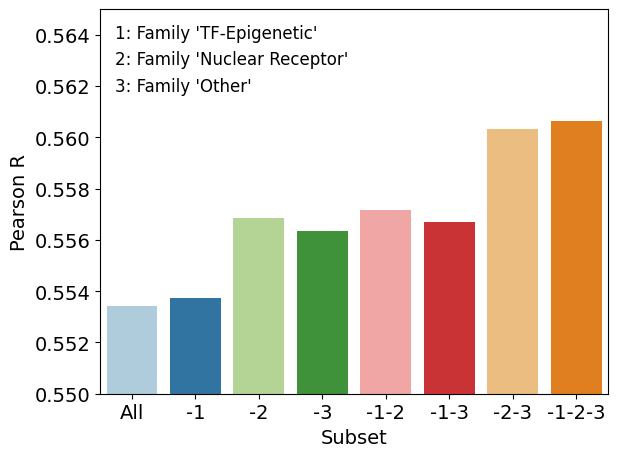

In [33]:
from matplotlib import patches as mpatches
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots()
sns.barplot(out_df, x="Subset", y="Pearson R", palette="Paired", ax=ax)
labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=0, ha='center',  rotation_mode='anchor')
ax.set_ylim([0.55, 0.565])

legend_mapping = {
    "1": "Family 'TF-Epigenetic'",
    "2": "Family 'Nuclear Receptor'",
    "3": "Family 'Other'"
}

# 2. Create "invisible" handles
# We use color='none' to make the box invisible, creating a text-only list
legend_handles = [
    mpatches.Patch(color='none', label=f"{key}: {value}") 
    for key, value in legend_mapping.items()
]

# 3. Add the legend to the plot
ax.legend(
    handles=legend_handles,
    loc="upper left",       # Position (good for your specific empty space)
    handlelength=0,         # Hides the handle icon space
    handletextpad=0,        # Removes padding between icon and text
    frameon=False,          # Optional: Removes the box border for a cleaner look
    fontsize=12             # Adjust size if necessary
)

plt.tight_layout()
plt.show()

## Effects of MD data-backup

In [18]:
lp_test_with_md = lp_test_ids.intersection(smart_logic_pdb_ids)

In [28]:
result_csv_nomd = "/ai/share/workspace/sxia/scripts/pignet_md_dev/results_archive/pignet_baseline_models/pignet_lppdbbind/test_scores/scores_lp_pdbbind.csv"
result_csv_md = "/ai/share/workspace/sxia/scripts/pignet_md_dev/results_whole_traj_hptune/lppdbbind_res0.1_frame50_head16_bs4/test_scores/scores_lp_pdbbind_no_md.csv"

result_df_nomd = pd.read_csv(result_csv_nomd).set_index("#code")
result_df_md = pd.read_csv(result_csv_md).set_index("#code")

In [34]:
affinity_file = "/ai/share/workspace/jhzhou/data/SiPobe_data/pdb_to_affinity_scoring.csv"
with open(affinity_file) as f:
    lines = f.readlines()
    lines = [l.split(',') for l in lines]
    id_to_y = {l[0]: float(l[1].split('\n')[0]) for l in lines}

In [48]:
result_df_combined = result_df_md.join(result_df_nomd, lsuffix="_md", rsuffix = "_nomd")
md_type = []
labels = []
for code in result_df_combined.index:
    if code in smart_logic_pdb_ids:
        md_type.append("MD")
    else:
        md_type.append("no-MD")
    labels.append(id_to_y[code])
result_df_combined["MD Type"] = md_type
result_df_combined["Experimental"] = labels
result_df_combined["Predicted (MD)"] = result_df_combined["score_md"] / -1.36
result_df_combined["Predicted (no MD)"] = result_df_combined["score_nomd"] / -1.36

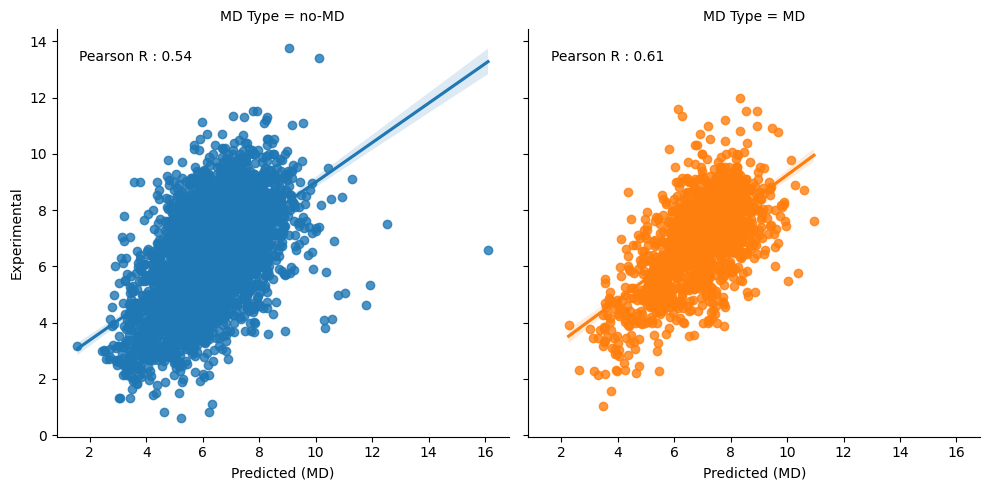

In [52]:
g = sns.lmplot(result_df_combined, x="Predicted (MD)", y="Experimental", hue="MD Type", col="MD Type")
for ax in g.axes.flat:
    # Get the data for the current facet
    class_name = ax.get_title().split('=')[1].strip()
    hue_subset = result_df_combined[(result_df_combined['MD Type'] == class_name)] # Adjust based on your facet variable
    if hue_subset.shape[0] < 2:
        continue
        
    # Calculate R-squared
    r, __ = pearsonr(hue_subset['Predicted (MD)'].values, hue_subset['Experimental'].values)

    # Add R-squared as text annotation
    # Adjust coordinates as needed for placement
    ax.text(0.05, 0.95 - (0.1 * len(ax.texts)), f'Pearson R : {r:.2f}',
            transform=ax.transAxes, verticalalignment='top')

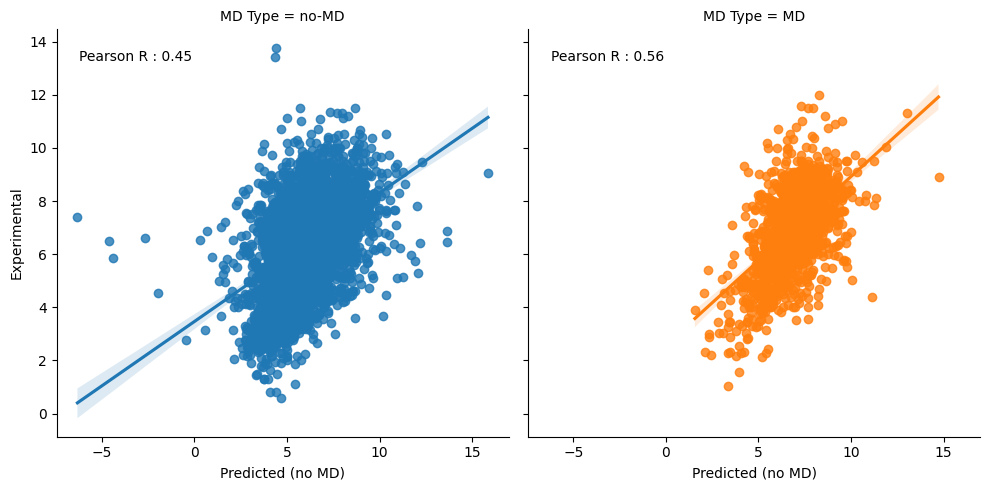

In [53]:
g = sns.lmplot(result_df_combined, x="Predicted (no MD)", y="Experimental", hue="MD Type", col="MD Type")
for ax in g.axes.flat:
    # Get the data for the current facet
    class_name = ax.get_title().split('=')[1].strip()
    hue_subset = result_df_combined[(result_df_combined['MD Type'] == class_name)] # Adjust based on your facet variable
    if hue_subset.shape[0] < 2:
        continue
        
    # Calculate R-squared
    r, __ = pearsonr(hue_subset['Predicted (no MD)'].values, hue_subset['Experimental'].values)

    # Add R-squared as text annotation
    # Adjust coordinates as needed for placement
    ax.text(0.05, 0.95 - (0.1 * len(ax.texts)), f'Pearson R : {r:.2f}',
            transform=ax.transAxes, verticalalignment='top')

In [66]:
exp = []
pred = []
for this_md_type in ["MD", "no-MD"]:
    hue_subset = result_df_combined[(result_df_combined['MD Type'] == this_md_type)]
    exp.append(hue_subset["Experimental"].values)
    if this_md_type == "no-MD":
        pred.append(hue_subset["Predicted (MD)"].values)
    else:
        pred.append(hue_subset["Predicted (no MD)"].values)
exp = np.concatenate(exp)
pred = np.concatenate(pred)

In [67]:
r, __ = pearsonr(exp, pred)
r

0.5521725068629741

## Effects of MD data-simulation time

In [25]:
performance_info = {"Static": 0.4885, "1ns": 0.5128, "10ns": 0.5145, "100ns": 0.5240, "250ns": 0.5373, "500ns": 0.5534}
performance_df = pd.DataFrame(performance_info, index=["Pearson R"])
performance_df = performance_df.T
performance_df.index.name = "Simulation Time"
performance_df = performance_df.reset_index()
performance_df

,Simulation Time,Pearson R
0,Static,0.4885
1,1ns,0.5128
2,10ns,0.5145
3,100ns,0.5240
4,250ns,0.5373
5,500ns,0.5534


/tmp/ipykernel_2077793/712915451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(performance_df, x="Simulation Time", y="Pearson R", palette="deep")


(0.46, 0.565)

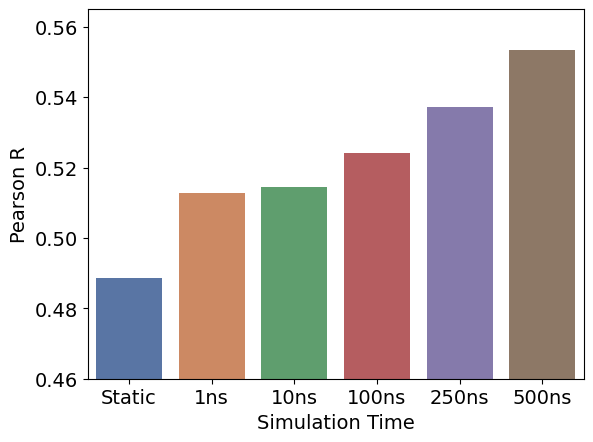

In [27]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots()

sns.barplot(performance_df, x="Simulation Time", y="Pearson R", palette="deep")
ax.set_ylim([0.46, 0.565])

## Effects of MD data-number of samples

In [31]:
performance_info = {"0 (Static)": 0.4885, "300": 0.5105, "1000": 0.5305, "3000": 0.5534}
performance_df = pd.DataFrame(performance_info, index=["Pearson R"])
performance_df = performance_df.T
performance_df.index.name = "Number of Protein-Ligand Pairs"
performance_df = performance_df.reset_index()
performance_df

,Number of Protein-Ligand Pairs,Pearson R
0,0 (Static),0.4885
1,300,0.5105
2,1000,0.5305
3,3000,0.5534


/tmp/ipykernel_2077793/280838411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(performance_df, x="Number of Protein-Ligand Pairs", y="Pearson R", palette="deep")


(0.46, 0.565)

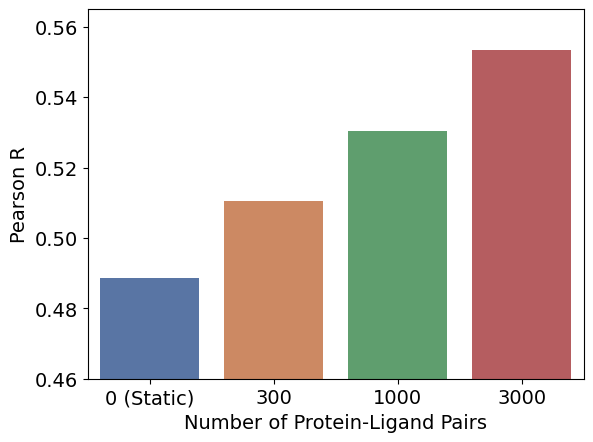

In [32]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots()

sns.barplot(performance_df, x="Number of Protein-Ligand Pairs", y="Pearson R", palette="deep")
ax.set_ylim([0.46, 0.565])

## CASF: Effects of MD data - simulation time

In [3]:
performance_info = {"Static": 0.803, "10ns": 0.8096, "100ns": 0.8152, "500ns": 0.8174}
performance_df = pd.DataFrame(performance_info, index=["Pearson R"])
performance_df = performance_df.T
performance_df.index.name = "Simulation Time"
performance_df = performance_df.reset_index()
performance_df

,Simulation Time,Pearson R
0,Static,0.8030
1,10ns,0.8096
2,100ns,0.8152
3,500ns,0.8174


/tmp/ipykernel_3835107/845853787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(performance_df, x="Simulation Time", y="Pearson R", palette="deep")


(0.795, 0.825)

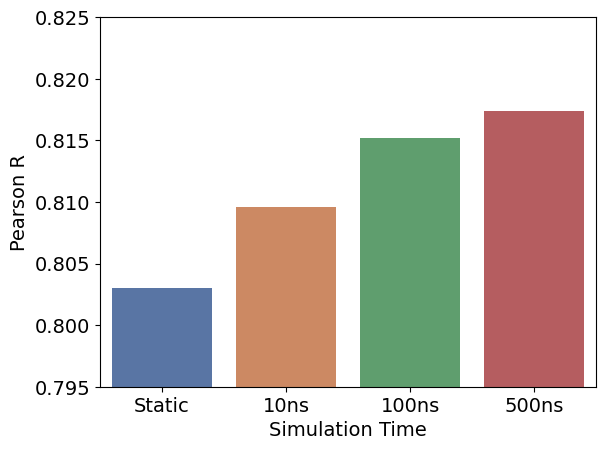

In [5]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots()

sns.barplot(performance_df, x="Simulation Time", y="Pearson R", palette="deep")
ax.set_ylim([0.795, 0.825])

## CASF: Effects of MD data-number of samples

In [7]:
performance_info = {"0 (Static)": 0.803, "1000": 0.8088, "2000": 0.8116, "3000": 0.8174}
performance_df = pd.DataFrame(performance_info, index=["Pearson R"])
performance_df = performance_df.T
performance_df.index.name = "Number of Protein-Ligand Pairs"
performance_df = performance_df.reset_index()
performance_df

,Number of Protein-Ligand Pairs,Pearson R
0,0 (Static),0.8030
1,1000,0.8088
2,2000,0.8116
3,3000,0.8174


/tmp/ipykernel_3835107/1538857759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(performance_df, x="Number of Protein-Ligand Pairs", y="Pearson R", palette="deep")


(0.795, 0.825)

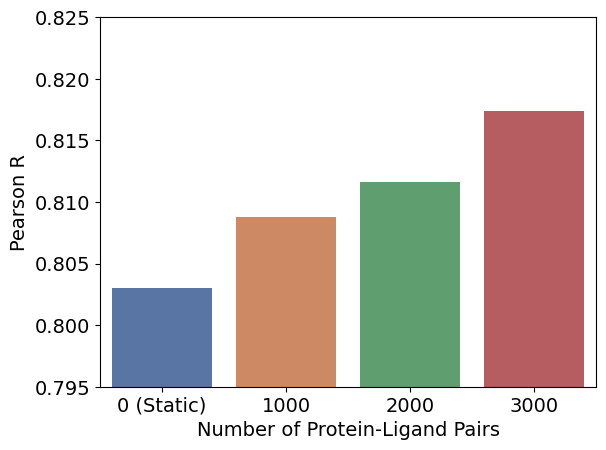

In [8]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots()

sns.barplot(performance_df, x="Number of Protein-Ligand Pairs", y="Pearson R", palette="deep")
ax.set_ylim([0.795, 0.825])